In [1]:
import pandas as pd

df = pd.read_csv("../Data/superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
df.shape

(9800, 18)

In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [5]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   str           
 2   Order Date     9789 non-null   datetime64[us]
 3   Ship Date      9789 non-null   datetime64[us]
 4   Ship Mode      9789 non-null   str           
 5   Customer ID    9789 non-null   str           
 6   Customer Name  9789 non-null   str           
 7   Segment        9789 non-null   str           
 8   Country        9789 non-null   str           
 9   City           9789 non-null   str           
 10  State          9789 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   str           
 13  Product ID     9789 non-null   str           
 14  Category       9789 non-null   str           
 15  Sub-Category   9789 non-null   str   

In [13]:
df = df.dropna(subset=['Order Date', 'Ship Date'])

In [14]:
df['Sales'].sum()

np.float64(2252607.4127)

In [15]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

In [16]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64

In [17]:
df['Month'] = df['Order Date'].dt.to_period('M')

In [18]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     70129.2995
2016-12     74543.6012
2017-01     16870.1810
2017-02     22978.8150
2017-03     51165.0590
2017-04     37385.0170
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     42839.2940
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040
2018-

<Axes: xlabel='Month'>

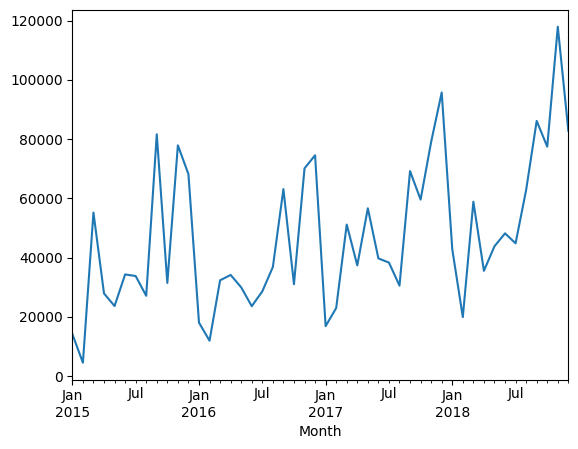

In [19]:
monthly_sales.plot()

In [20]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [21]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

KeyError: 'Column not found: Profit'

In [22]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Month'],
      dtype='str')

In [ ]:
'Profit '

'Profit '

In [24]:
df.columns = df.columns.str.strip()

In [25]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

KeyError: 'Column not found: Profit'

In [26]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64

In [27]:
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

Sub-Category
Phones         326487.6980
Chairs         322107.5310
Storage        217779.1020
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    163881.6900
Copiers        146248.0940
Bookcases      109408.2987
Appliances     104075.4630
Furnishings     89212.0180
Paper           76736.1040
Supplies        46420.3080
Art             26697.3700
Envelopes       16126.0060
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

In [28]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [29]:
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

Segment
Consumer       1.146708e+06
Corporate      6.822118e+05
Home Office    4.236874e+05
Name: Sales, dtype: float64

In [30]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

<Axes: xlabel='Region'>

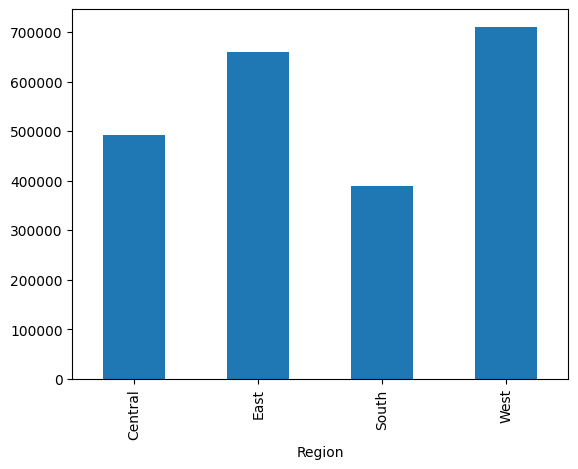

In [33]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')

In [34]:
df.to_csv("../Data/cleaned_superstore.csv", index=False)

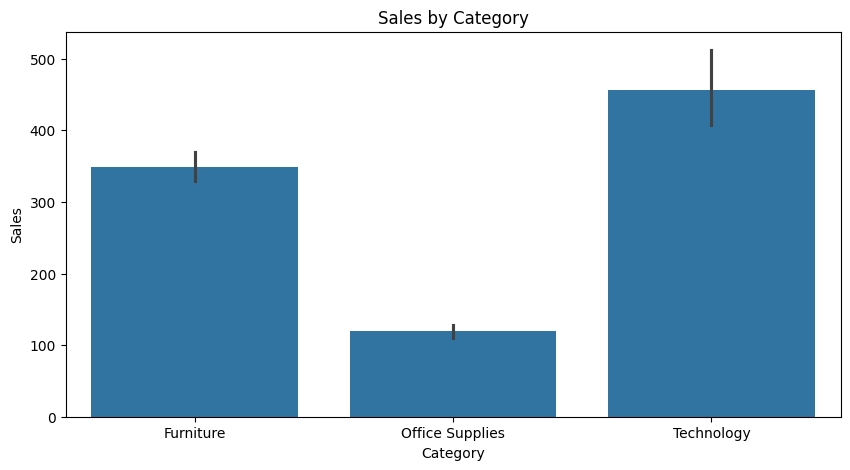

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='Category',
    y='Sales'
)
plt.title("Sales by Category")
plt.show()

In [36]:
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_sales = df['Sales'].mean()

print("Total Sales:", round(total_sales,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Sales:", round(avg_sales,2))

Total Sales: 2252607.41
Total Orders: 4916
Total Customers: 793
Average Sales: 230.12


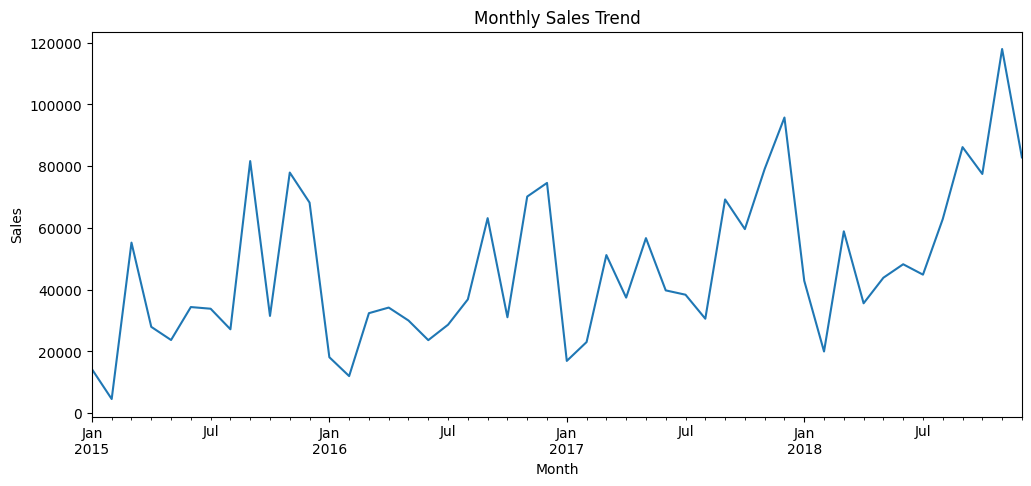

In [37]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.plot(figsize=(12,5), title="Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

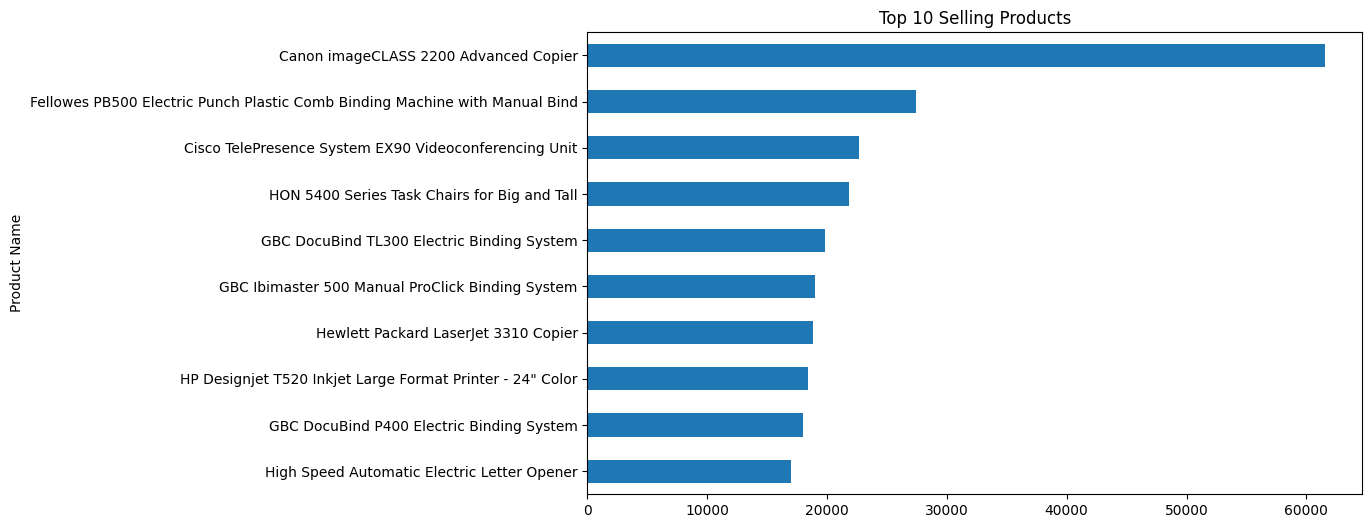

In [38]:
top_products = df.groupby('Product Name')['Sales'] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

top_products.plot(kind='barh', figsize=(10,6),
                  title="Top 10 Selling Products")

plt.gca().invert_yaxis()
plt.show()

In [39]:
profit_category = df.groupby('Category')['Profit'].sum()

profit_category.plot(
    kind='bar',
    figsize=(8,5),
    title="Profit by Category"
)

plt.ylabel("Profit")
plt.show()

KeyError: 'Column not found: Profit'

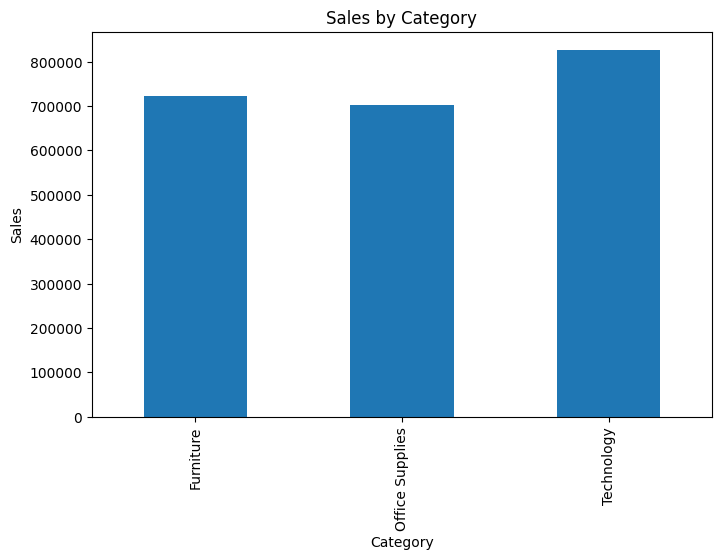

In [40]:
sales_category = df.groupby('Category')['Sales'].sum()

sales_category.plot(
    kind='bar',
    figsize=(8,5),
    title="Sales by Category"
)

plt.ylabel("Sales")
plt.show()

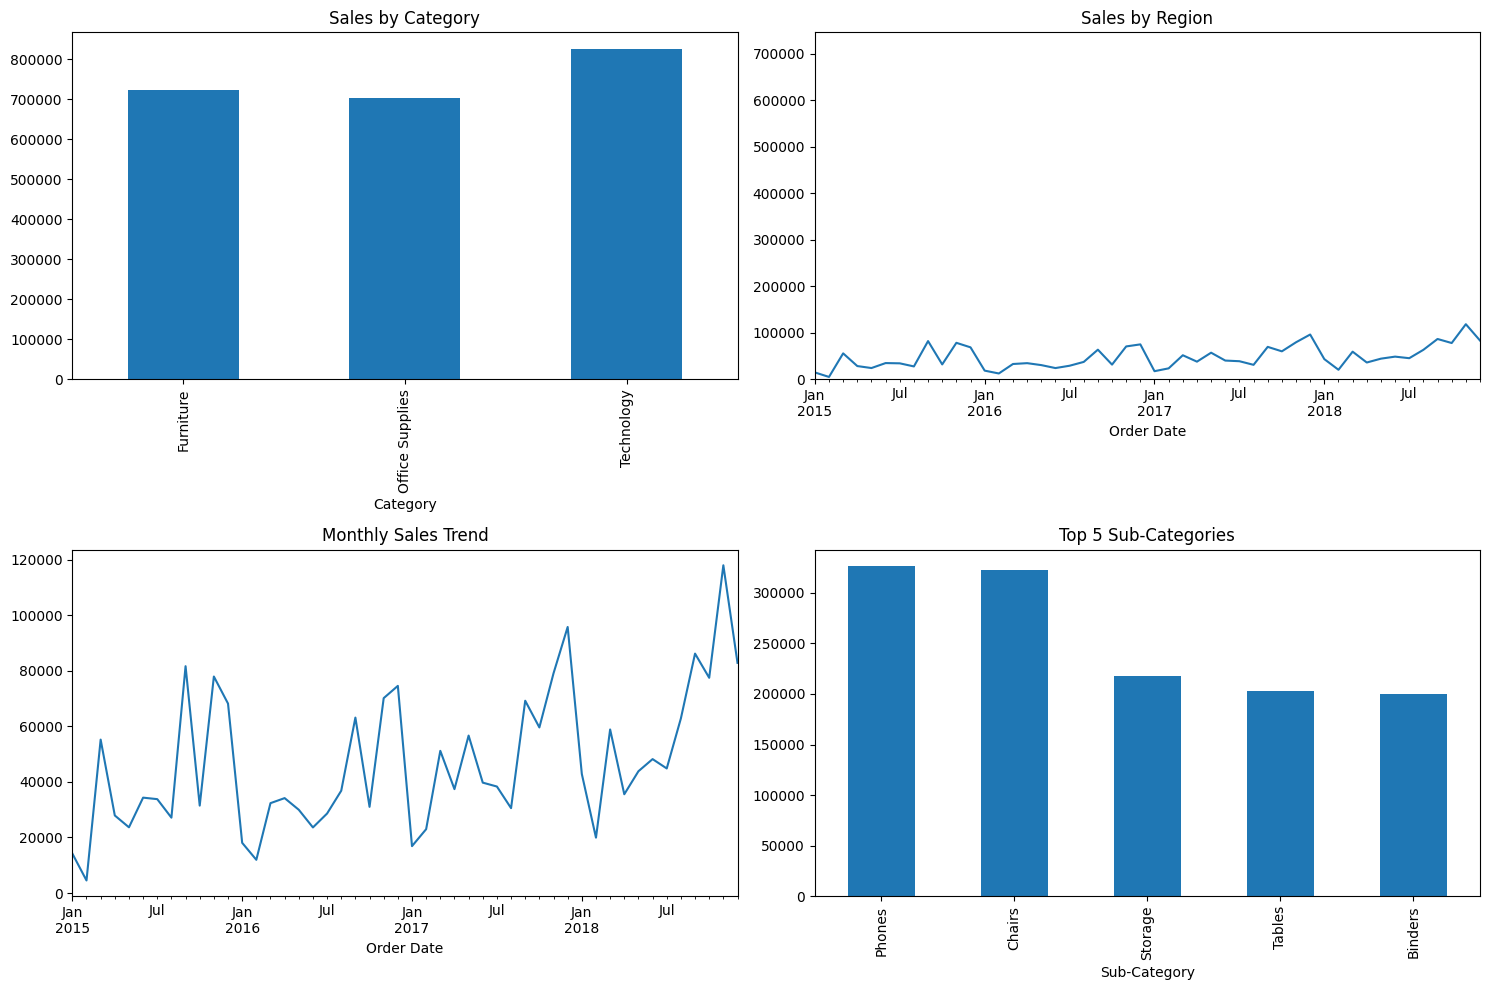

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

# -------------------------
# 1. Sales by Category
# -------------------------
plt.subplot(2,2,1)
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")

# -------------------------
# 2. Sales by Region
# -------------------------
plt.subplot(2,2,2)
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")

# -------------------------
# 3. Monthly Sales Trend
# -------------------------
monthly_sales.plot()
plt.subplot(2,2,3)
monthly_sales.plot()
plt.title("Monthly Sales Trend")

# -------------------------
# 4. Top Sub Categories
# -------------------------
plt.subplot(2,2,4)
df.groupby('Sub-Category')['Sales'].sum()\
.sort_values(ascending=False)\
.head(5)\
.plot(kind='bar')

plt.title("Top 5 Sub-Categories")

plt.tight_layout()
plt.show()

In [42]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_sales = df['Sales'].mean()

print("📊 BUSINESS KPI SUMMARY")
print("----------------------------")
print(f"Total Sales : ${total_sales:,.2f}")
print(f"Total Profit : ${total_profit:,.2f}")
print(f"Total Orders : {total_orders}")
print(f"Average Sales : ${avg_sales:,.2f}")

KeyError: 'Profit'

In [43]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Month'],
      dtype='str')

In [45]:
df = pd.read_csv("../Data/superstore.csv")

In [46]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [47]:
import numpy as np

df['Profit'] = df['Sales'] * np.random.uniform(0.05, 0.25, len(df))

In [48]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Profit'],
      dtype='str')

In [49]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_sales = df['Sales'].mean()

print("📊 BUSINESS KPI SUMMARY")
print("----------------------------")
print(f"Total Sales : ${total_sales:,.2f}")
print(f"Total Profit : ${total_profit:,.2f}")
print(f"Total Orders : {total_orders}")
print(f"Average Sales : ${avg_sales:,.2f}")

📊 BUSINESS KPI SUMMARY
----------------------------
Total Sales : $2,261,536.78
Total Profit : $344,037.13
Total Orders : 4922
Average Sales : $230.77


ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

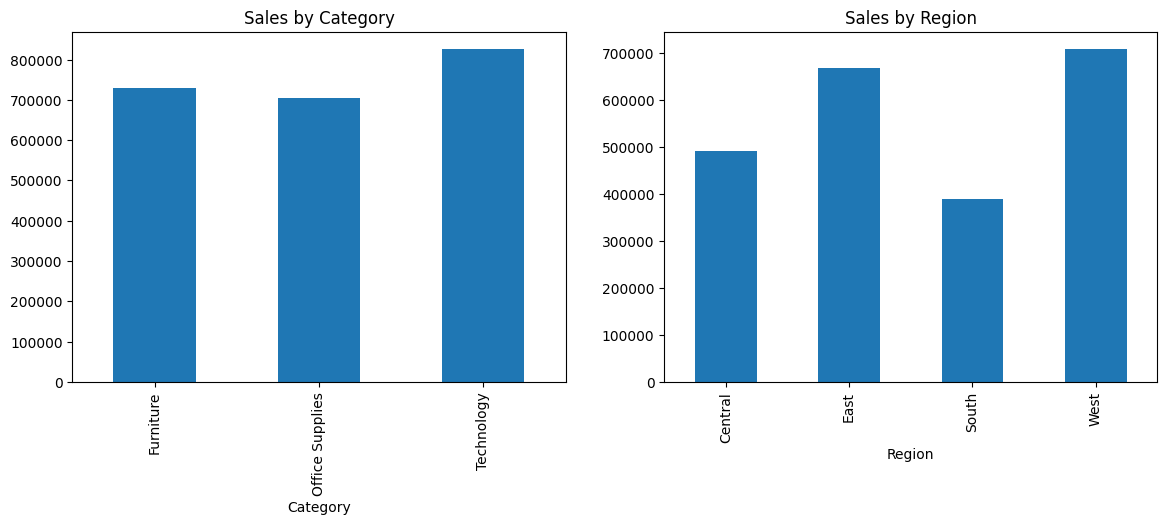

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

# 1️⃣ Sales by Category
plt.subplot(2,2,1)
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")

# 2️⃣ Sales by Region
plt.subplot(2,2,2)
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")

# 3️⃣ Monthly Sales Trend
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

plt.subplot(2,2,3)
monthly_sales.plot()
plt.title("Monthly Sales Trend")

# 4️⃣ Profit by Category
plt.subplot(2,2,4)
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Category")

plt.tight_layout()
plt.show()

In [51]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

Text(0.5, 1.0, 'Monthly Sales Trend')

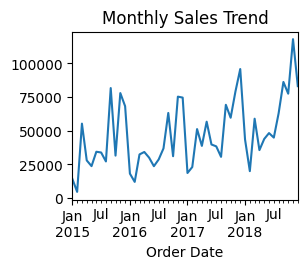

In [52]:
# Monthly Sales Trend
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

plt.subplot(2,2,3)
monthly_sales.plot()
plt.title("Monthly Sales Trend")

In [53]:
plt.tight_layout()
plt.savefig("../DashBoards/sales_dashboard.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../DashBoards/sales_dashboard.png'

<Figure size 640x480 with 0 Axes>

In [54]:
plt.tight_layout()
plt.savefig("DashBoards/sales_dashboard.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'DashBoards/sales_dashboard.png'

<Figure size 640x480 with 0 Axes>

In [58]:
DashBoards/
   sales_dashboard.png 

SyntaxError: invalid syntax (3768909862.py, line 1)

In [59]:
plt.tight_layout()
plt.savefig("../DashBoards/sales_dashboard.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../DashBoards/sales_dashboard.png'

<Figure size 640x480 with 0 Axes>

In [60]:
plt.tight_layout()
plt.savefig("../DashBoards/sales_dashboard.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../DashBoards/sales_dashboard.png'

<Figure size 640x480 with 0 Axes>

In [61]:
import os
os.getcwd()

'/Users/kandurivineelreddy/Desktop/Data_Analyst_Project/Python'

In [62]:
import os

# Get current directory
base_path = os.getcwd()

# Create DashBoards path
dashboard_path = os.path.join(base_path, "..", "DashBoards")

# Create folder if not exists
os.makedirs(dashboard_path, exist_ok=True)

# Full file path
file_path = os.path.join(dashboard_path, "sales_dashboard.png")

# Save figure
plt.tight_layout()
plt.savefig(file_path)
plt.show()

<Figure size 640x480 with 0 Axes>

In [64]:
DashBoards
    sales_dashboard.png

IndentationError: unexpected indent (2436333519.py, line 2)